# Implementing the Backpropagation Algorithm

A Multilayer Perceptron (MLP) neural network is trained using the Backpropagation Algorithm on a challenging 8-class dataset. This report documents the full pipeline, covering data preprocessing and class balancing, architecture design and mathematical formulation, iterative hyperparameter tuning, and model evaluation.

## Initializing the Libraries

The following libraries are required:

| Library | Purpose |
|---------|--------|
| `numpy` | Numerical operations, matrix math, vectorized computations |
| `matplotlib` | Plotting learning curves and dataset distributions |
| `imblearn` | SMOTE for handling class imbalance (depends on `scipy`) |
| `os`, `csv` | File I/O for loading datasets and exporting results |
| `time` | Tracking training duration |

In [1]:
%pip install numpy matplotlib 
%pip install imblearn imbalanced-learn

#imbalanced learn (dependent on scipy) is neaded for SMOTE.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
!python --version
!pip list | grep -E "imblearn"

Python 3.12.2
imblearn                          0.0


# The Dataset

## Loading the Dataset

The dataset is loaded from CSV files in the `dataset/` directory. Features are dense numerical vectors with 3486 dimensions, and labels range from 1 to 8 (8 classes). Labels are one-hot encoded into an `(N, 8)` matrix for the output layer — each row has a `1.0` at the index corresponding to its class.

A separate unlabeled test set is also loaded for final predictions.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os, csv

# loading the data
DATASET     = np.loadtxt(os.path.join("dataset", "data.csv"), delimiter=",")
DATALABELS  = np.loadtxt(os.path.join("dataset", "data_labels.csv"), delimiter=",", dtype=int)
TESTSET     = np.loadtxt(os.path.join("dataset", "test_set.csv"), delimiter=",")

print(f"DATASET : {DATASET.shape}")
print(f"DATALABELS : {DATALABELS.shape}  classes: {np.unique(DATALABELS)}")
print(f"TESTSET : {TESTSET.shape}")

CLASSES = int(np.max(DATALABELS)) #1,2,3,4,5,6,7,8
LABELS = np.zeros((len(DATALABELS), CLASSES), dtype=float) #what class is the data
for _i, label in enumerate(DATALABELS):
    LABELS[_i, int(label) - 1] = 1.0

print(f"LABELS   : {LABELS.shape}")
print(f"Sample   : label {DATALABELS[0]} → {LABELS[0]}")


DATASET : (3486, 354)
DATALABELS : (3486,)  classes: [1 2 3 4 5 6 7 8]
TESTSET : (701, 354)
LABELS   : (3486, 8)
Sample   : label 8 → [0. 0. 0. 0. 0. 0. 0. 1.]


## Dataset Distribution

To observe how balanced or unbalanced the dataset is, a pie chart is generated showing the class distribution.

This is a critical step: imbalanced data can cause the network to become biased toward the majority class, predicting it disproportionately and ignoring minority classes entirely.

In [4]:

def piechart(datalabels, title='Class Distribution'): #use trainingset labels
    classcounts = np.bincount(datalabels, minlength=9)[1:]
    labels = [f"Class {i}" for i in range(1, len(classcounts) + 1)]

    plt.figure(figsize=(10, 8))
    plt.pie(classcounts, autopct=lambda pct: f'{int(pct/100.*sum(classcounts))}\n({pct:.1f}%)', startangle=90)
    plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1))
    plt.title(title)
    plt.axis('equal')
    plt.show()

    os.makedirs('figures', exist_ok=True)
    filename = title.replace(' ', '_').lower() + '.png'
    filepath = os.path.join('figures', filename)
    plt.savefig(filepath, bbox_inches='tight', dpi=100)
    plt.close()
    print(f"Figure saved to {filepath}")

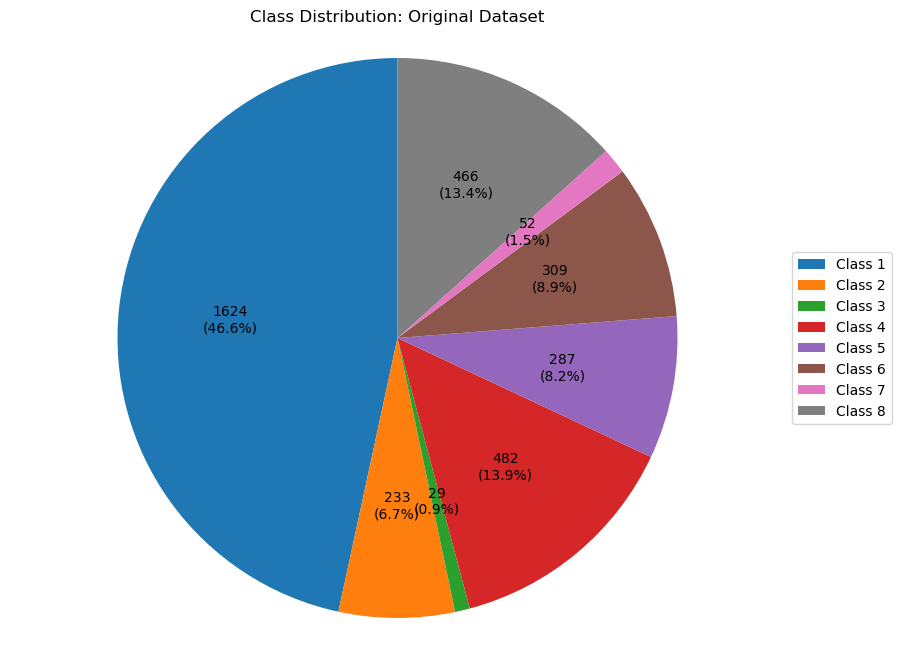

Figure saved to figures/class_distribution:_original_dataset.png


In [11]:
piechart(DATALABELS, "Class Distribution: Original Dataset") #the original

The distribution reveals a significant imbalance. **Class 1 dominates with 46.6%** of the dataset, while **Class 4 holds the smallest share**. This level of skew indicates that class balancing is necessary before training; without it, the network is likely to learn a trivial solution of always predicting the majority class.

## SMOTE (Synthetic Minority Over-sampling Technique)

To address the class imbalance, **SMOTE** is applied to the dataset. SMOTE generates synthetic samples for minority classes by interpolating between existing samples, effectively balancing the class distribution without simply duplicating data points.

In [5]:
X = DATASET
y = DATALABELS

from imblearn.over_sampling import SMOTE

X_balanced, y_balanced = SMOTE(random_state=50).fit_resample(X, y)

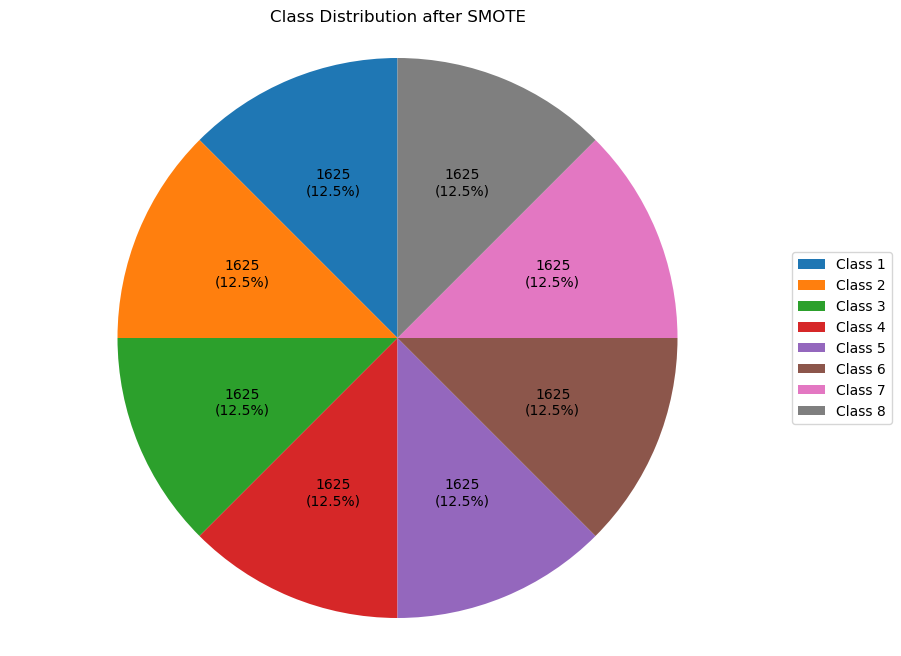

Figure saved to figures/class_distribution_after_smote.png


In [6]:
piechart(y_balanced, "Class Distribution after SMOTE")

The dataset is now balanced and ready for training: each class contains an equal number of samples, as confirmed by the pie chart.

> **Note on data leakage:** In this implementation, SMOTE was applied *before* splitting into training and validation sets. This means synthetic samples could influence the validation set, potentially leading to optimistic evaluation metrics. Ideally, SMOTE should only be applied to the training fold after the split. This trade-off was accepted for simplicity but is worth noting.

## Partitioning the Dataset

Now that the dataset is balanced and randomized, it is partitioned into training and validation sets using a custom `Partition` class.

- **Validation set:** 800 samples (randomly selected, `random_state=50`)
- **Training set:** remaining samples

The partitions are exported to CSV files (`training_set.csv`, `training_labels.csv`, `validation_set.csv`, `validation_labels.csv`) for reproducibility.

In [9]:
valsize = 800 # fixed validation set size

class Partition: #X is the dataset, y is the datalabels
    def __init__(self, X, y, valsize=800, outputdir="export", randomstate=50):
        os.makedirs(outputdir, exist_ok=True)
        rng = np.random.default_rng(randomstate)

        indices = rng.permutation(len(X))
        validx, trainidx = indices[:valsize], indices[valsize:]

        Xtrain, ytrain = X[trainidx], y[trainidx]
        Xval, yval = X[validx], y[validx]

        self.classes = np.unique(y)
        self.outputdir = outputdir
        self.validationset = Xval
        self.validationlabels = yval
        self.trainingset = Xtrain
        self.traininglabels = ytrain

        self.exportcsv(self.trainingset, "training_set.csv")
        self.exportcsv(self.traininglabels, "training_labels.csv")
        self.exportcsv(self.validationset, "validation_set.csv")
        self.exportcsv(self.validationlabels, "validation_labels.csv")

    def printdetails(self):
        print("Training Set Details")
        print(f"  Shape       : {self.trainingset.shape}")
        print(f"  Label shape : {self.traininglabels.shape}")
        # print(f"  Feature min : {self.trainingset.min():.6f}")
        # print(f"  Feature max : {self.trainingset.max():.6f}")
        # print(f"  Feature mean: {self.trainingset.mean():.6f}")
        print("\n  Class distribution:")
        total = len(self.traininglabels)
        for cls in self.classes:
            n = np.sum(self.traininglabels == cls)
            print(f"    Class {cls}: {n:>5}  ({n/total*100:.2f}%)")
        piechart(self.traininglabels, "Class Distribution of Training Set")
        print(f"\nValidation Set Details")
        print(f"  Shape       : {self.validationset.shape}")
        print(f"  Label shape : {self.validationlabels.shape}")
        piechart(self.validationlabels, "Class Distribution of Validation Set")

    #all export functions after split
    def exportcsv(self, data, filename):
        path = os.path.join(self.outputdir, filename)
        fmt = "%d" if data.ndim == 1 else "%g"
        np.savetxt(path, data, delimiter=",", fmt=fmt)
        print(f"Saved → {path}  shape: {data.shape}")

Saved → export/training_set.csv  shape: (12200, 354)
Saved → export/training_labels.csv  shape: (12200,)
Saved → export/validation_set.csv  shape: (800, 354)
Saved → export/validation_labels.csv  shape: (800,)
Training Set Details
  Shape       : (12200, 354)
  Label shape : (12200,)

  Class distribution:
    Class 1:  1536  (12.59%)
    Class 2:  1543  (12.65%)
    Class 3:  1519  (12.45%)
    Class 4:  1506  (12.34%)
    Class 5:  1531  (12.55%)
    Class 6:  1519  (12.45%)
    Class 7:  1523  (12.48%)
    Class 8:  1523  (12.48%)


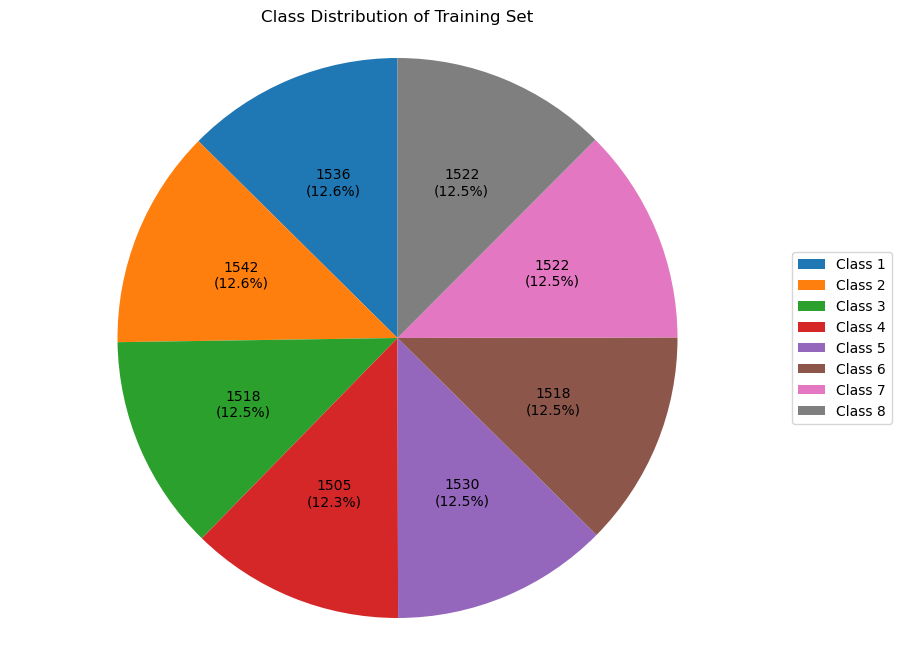

Figure saved to figures/class_distribution_of_training_set.png

Validation Set Details
  Shape       : (800, 354)
  Label shape : (800,)


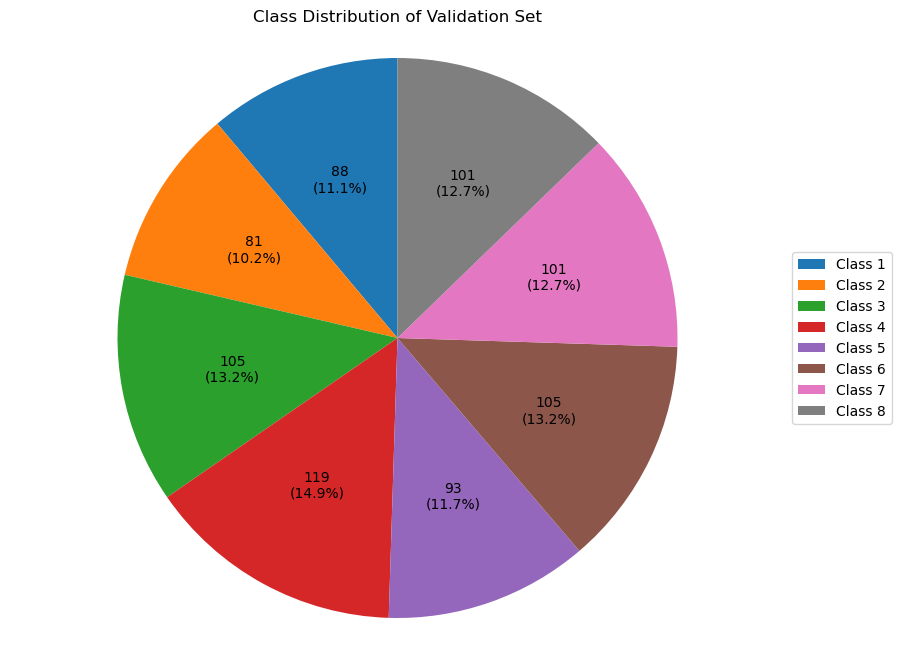

Figure saved to figures/class_distribution_of_validation_set.png


In [10]:
split = Partition(X_balanced, y_balanced)
split.printdetails()

## Batch Size

Mini-batch gradient descent is used with a **batch size of 8**. A generator function `minibatch()` yields sequential slices of the training set and labels for each batch iteration. This allows vectorized computation within each batch while still updating weights multiple times per epoch.

In [12]:
def minibatch(trainingset, traininglabels, batch_size=8):
    N = len(trainingset)
    indices = np.arange(N)
    for start in range(0, N, batch_size):
        i = indices[start : start + batch_size]
        yield trainingset[i], traininglabels[i]

In [13]:
batch_size = 8 #edit this to get the batch size you need
minibatch(split.trainingset, split.traininglabels, batch_size)

<generator object minibatch at 0x302eef240>

# Setting up the Equations

The backpropagation algorithm is defined by a sequence of mathematical equations that govern forward propagation, error computation, delta calculation, and weight updating. The following sections lay out each equation as implemented in the code.

## Full Equation Reference: Backpropagation Algorithm

> **Notation**
> | Symbol | Meaning |
> |--------|---------|
> | $L$ | Total number of layers (output layer index) |
> | $l$ | Current layer index, $l \in \{1, \dots, L\}$ |
> | $i$ | Index of neuron in layer $l-1$; $i = 0$ is the bias input |
> | $j$ | Index of neuron in layer $l$ |
> | $k$ | Index of neuron in output layer $L$ |
> | $w^{(l)}_{j0}$ | Bias weight of neuron $j$ in layer $l$ (fixed input $\varphi_0 = +1$) |
> | $w^{(l)}_{ji}$ | Weight from neuron $i$ in layer $l-1$ to neuron $j$ in layer $l$ |
> | $v^{(l)}_j$ | Internal activity (pre-activation) of neuron $j$ in layer $l$ |
> | $\varphi_j$ | Activation function of neuron $j$; output $\varphi_j\!\left(v^{(l)}_j\right)$ |
> | $d_k$ | Desired (target) output for output neuron $k$ |
> | $e_k(n)$ | Error at output neuron $k$ at epoch $n$ |
> | $\mathcal{E}(n)$ | Mean square error over all output neurons at epoch $n$ |
> | $\eta$ | Learning rate |
> | $\alpha$ | Momentum coefficient |
> | $a, b$ | Depends on activation function. Used by Logistic and Tanh as constant/s, Leaky ReLU negative-side slope, $\gamma \in (0,1)$ |
> | $n$ | Discrete time step (epoch) |
 
---

## 1. Forward Propagation to get internal activity $v(n)$ and outputs $y_{out}$

### 1.1 Internal Activity
 
The sum begins at $i = 0$ to include the bias weight $w^{(l)}_{j0}$ directly. The bias neuron has a fixed output of $+1$, so $w^{(l)}_{j0} \cdot 1 = w^{(l)}_{j0}$:
 
$$v^{(l)}_j(n) = \sum_{i=0}^{p} w^{(l)}_{ji}(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
where $p$ is the number of neurons in layer $l-1$ (excluding the bias), and the bias input is $\varphi_0 = +1$ (constant).
 
### 1.2 Neuron Output
 
$$y_j(n) = \varphi_j\!\left(v^{(l)}_j(n)\right)$$
 
where $\varphi_j$ is the chosen activation function (see Section 2).

## 2. Choosing the Activation Functions
 
Derivatives are expressed in terms of the neuron output $o(n) = \varphi(v(n))$ directly, using constants $a$ and $b$ where applicable.
 
### 2.1 Logistic (Sigmoid)
 
$$\varphi(v) = \frac{1}{1 + e^{-av}}, \quad a > 0$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = a \cdot o(n)\,\bigl(1 - o(n)\bigr)$$

> Given: $a = 2.0$
 
---
 
### 2.2 Hyperbolic Tangent (Tanh)
 
$$\varphi(v) = a \tanh(bv) = a \cdot \frac{e^{bv} - e^{-bv}}{e^{bv} + e^{-bv}}$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \frac{b}{a}\left(a - o(n)\right)\!\left(a + o(n)\right)$$
 
> Given: $a = 1.716,\; b = 0.66667$
 
---
 
### 2.3 Leaky ReLU
 
$$\varphi(v) = \begin{cases} v & \text{if } v > 0 \\ \gamma\, v & \text{if } v \leq 0 \end{cases}, \quad \gamma \in (0,1)$$
 
**Derivative (in terms of output $o(n) = \varphi(v(n))$):**
 
$$\varphi'(v) = \begin{cases} 1 & \text{if } o(n) > 0 \\ \gamma & \text{if } o(n) \leq 0 \end{cases}$$
 
---

In [14]:
# ACTIVATION FUNCTIONS
def logistic(v, a=1.0):
    phi = 1.0 / (1.0 + np.exp(-a * v))
    return phi

def tanh(v, a=1.0, b=1.0):
    phi = a * np.tanh(b * v)
    return phi
 
def leakyrelu(v, gamma=0.01):
    phi = np.where(v > 0, v, gamma * v)
    return phi
 
def errorSignal(dk, phiVk):
    return dk - phiVk
 
def meanSquareError(ek):
    return 0.5 * np.dot(ek, ek)

# DERIVATIVES
RELU_CLIP = 5.0 #for relu to converge

def dlogistic(o, a=1.0):
    dphi = a * o * (1.0 - o)
    return dphi
 
def dtanh(o, a=1.0, b=1.0):
    dphi = (b / a) * (a - o) * (a + o)
    return dphi
 
def dleakyrelu(o, gamma=0.01):
    dphi = np.where(o > 0, 1.0, gamma)
    return dphi
 
# DERIVATIVE CALL
def callDerivative(method, o, config):
    if method == 0:
        return dlogistic(o, config['a_l']), None
    elif method == 1:
        return dtanh(o, config['a_tanh'], config['b_tanh']), None
    else:
        return dleakyrelu(o, config['a_relu']), RELU_CLIP
 
# ACTIVATION CALL
def callActivation(method, v, config):
    if method == 0:
        return logistic(v, config['a_l'])
    elif method == 1:
        return tanh(v, config['a_tanh'], config['b_tanh'])
    else:
        return leakyrelu(v, config['a_relu'])

## 3. Error & Mean Square Error
 
### 3.1 Error Signal at Output Neuron $k$
 
$$o_k(n)= s \varphi_k\!\left(v^{(L)}_k(n)\right)$$
 
### 3.2 Mean Square Error
 
$$\mathcal{E}(n) = \frac{1}{2} \sum_{k \in \mathcal{C}} e_k^2(n)$$
 
where $\mathcal{C}$ is the set of output neurons.
 
---

## 4. Backpropagation Delta Equations
 
### 4.1 Output Layer Delta
 
$$\delta^{(L)}_k(n) = e_k(n) \cdot \varphi'\!\left(v^{(L)}_k(n)\right)$$
 
### 4.2 Hidden Layer Delta
 
For layer $l \in \{L-1,\, L-2,\, \dots,\, 1\}$:
 
$$\delta^{(l)}_j(n) = \varphi'\!\left(v^{(l)}_j(n)\right) \cdot \sum_{k}\, \delta^{(l+1)}_k(n)\, w^{(l+1)}_{kj}(n)$$
 
The hidden-layer delta propagates the error signal backward by weighting each upstream delta $\delta^{(l+1)}_k$ by the corresponding weight $w^{(l+1)}_{kj}$ and scaling by the local derivative $\varphi'(v^{(l)}_j)$.
 
---

## 5. Weight Update: Negative Gradient with Momentum
 
All weights $w^{(l)}_{ji}$ include the bias weights at $i = 0$ (with fixed input $\varphi_0 = +1$). No separate bias update is needed.
 
The weight correction follows the **negative gradient** of $\mathcal{E}(n)$ with respect to $w^{(l)}_{ji}$:
 
$$-\frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)} = \delta^{(l)}_j(n) \cdot \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.1 Weight Increment (Generalized Delta Rule + Momentum)
 
$$\Delta w^{(l)}_{ji}(n) = \underbrace{\alpha\, \Delta w^{(l)}_{ji}(n-1)}_{\text{momentum}} \;-\; \underbrace{\eta\, \frac{\partial \mathcal{E}(n)}{\partial w^{(l)}_{ji}(n)}}_{\text{negative gradient}}$$
 
Substituting the gradient expression:
 
$$\Delta w^{(l)}_{ji}(n) = \alpha\, \Delta w^{(l)}_{ji}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)\, \varphi_i\!\left(v^{(l-1)}_i(n)\right)$$
 
### 5.2 Weight Update Rule
 
$$w^{(l)}_{ji}(n+1) = w^{(l)}_{ji}(n) + \Delta w^{(l)}_{ji}(n)$$
 
> **Bias weights** ($i = 0$) are updated identically using $\varphi_0 = +1$, so:
> $$\Delta w^{(l)}_{j0}(n) = \alpha\, \Delta w^{(l)}_{j0}(n-1) \;+\; \eta\, \delta^{(l)}_j(n)$$
 
> **Momentum note:** When $\alpha = 0$, this reduces to the standard (vanilla) delta rule. When $\alpha > 0$, the update accumulates a fraction of the previous step, smoothing oscillations and accelerating convergence along consistent gradient directions.
 
---

In [16]:
class OutputLayer:
    def __init__(self, method, w_old, config, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.o = []
        self.d = []
        self.w_old = w_old
        self.size = config['size']
        self.delta = []
        self.error = []
        self.mse = 0.0
        self.w_new = []
        self.totaltime = 0
 
        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.o = callActivation(self.method, self.v, self.config)
 
    def computeError(self, d):
        self.d = np.asarray(d, dtype=float)
        self.error = errorSignal(self.d, self.o)
        self.mse = meanSquareError(self.error)
 
    def computeDelta(self):
        dphi, _ = callDerivative(self.method, self.o, self.config)
        self.delta = self.error * dphi
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
 
 
class HiddenLayer:
    def __init__(self, method, w_old, config, size=8, dw_prev=None):
        self.config = config
        self.method = method
        self.v = []
        self.y = []
        self.w_old = w_old
        self.size = size
        self.delta = 0.0
        self.w_new = []

        self.dw_prev = dw_prev if dw_prev is not None else np.zeros_like(w_old)
        self.phiIn = None
        self.gradient = np.zeros_like(w_old)
 
    def forward(self, phiIn):
        self.phiIn = phiIn
        self.v = self.w_old @ phiIn
        self.y = callActivation(self.method, self.v, self.config)
        return np.concatenate(([1.0], self.y))
 
    def computeDelta(self, nextLayer):
        dphi, _ = callDerivative(self.method, self.y, self.config)
        w_nobias = nextLayer.w_old[:, 1:]
        propagated = w_nobias.T @ nextLayer.delta
        self.delta = dphi * propagated
 
    def accumulateGradient(self):
        self.gradient += np.outer(self.delta, self.phiIn)
 
    def resetGradient(self):
        self.gradient = np.zeros_like(self.w_old)
 
    def updateWeights(self, batch_size=1):
        dw = self.config['alpha'] * self.dw_prev + self.config['eta'] * (self.gradient / batch_size)
        _, clip = callDerivative(self.method, self.y, self.config)
        if clip is not None:
            norm = np.linalg.norm(dw)
            if norm > clip:
                dw = dw * (clip / norm)
        self.w_new = self.w_old + dw
        self.dw_prev = dw
        self.gradient = np.zeros_like(self.w_old)
        return self.w_new
 
 
class Epoch:
    def __init__(self, split, config):
        self.config = config
        self.label = ""
        inputsize  = split.trainingset.shape[1] + 1
        hiddensize = config['size']
        outputsize = len(split.classes)
        #randomizing start weights
        
        np.random.seed(50) #for reproducibility
        Wi = np.random.randn(hiddensize, inputsize) * 0.01
        Wj = np.random.randn(hiddensize, hiddensize + 1)  * 0.01
        Wk = np.random.randn(outputsize, hiddensize + 1)  * 0.01

        self.hiddenlayer_i = HiddenLayer(config['methods'][0], Wi, config, size=hiddensize)
        self.hiddenlayer_j = HiddenLayer(config['methods'][1], Wj, config, size=hiddensize)
        self.outputlayer_k = OutputLayer(config['methods'][2], Wk, config)

        self.test_set = list(zip(split.validationset, split.validationlabels))
        self.error = 0.0 #for scores
        
        self.batch_iteration = 0
        self.epoch_iteration = 0

        #for export
        self.train_errors = []
        self.val_errors = []
        self.epochs_logged = []
        self.misclassified = []
        
        self.tp = self.tn = self.fp = self.fn = 0.0
        self.p = self.r = self.a = self.f1 = self.matthews = 0.0

        self.trainingset = split.trainingset
        self.traininglabels = split.traininglabels
 
    def run(self, x, d):
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
 
        # Forward Prop
        phi_i = self.hiddenlayer_i.forward(x_biased)
        phi_j = self.hiddenlayer_j.forward(phi_i)
        self.outputlayer_k.forward(phi_j)
 
        outputsize = self.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(outputsize)
        d_onehot[int(d) - 1] = 1.0

        # Error calcs
        self.outputlayer_k.computeError(d_onehot)
        self.error = self.outputlayer_k.mse
 
        # Backprop
        self.outputlayer_k.computeDelta()
        self.hiddenlayer_j.computeDelta(self.outputlayer_k)
        self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
        # Accumulate (batch_size=1, so gradient = outer(delta, phiIn))
        self.outputlayer_k.accumulateGradient()
        self.hiddenlayer_j.accumulateGradient()
        self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates
        self.outputlayer_k.updateWeights()
        self.hiddenlayer_j.updateWeights()
        self.hiddenlayer_i.updateWeights()
 
        # Advance w_old → w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.epoch_iteration += 1
 
    def run_batch(self, X_batch, D_batch):
        batch_size = len(X_batch)
        error = 0.0
        misclassified = 0
 
        for SAMPLE in range(batch_size):
            x_biased = np.concatenate(([1.0], np.asarray(X_batch[SAMPLE], dtype=float)))
 
            # Forward Prop
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            outputsize = self.outputlayer_k.w_old.shape[0]
            d_onehot = np.zeros(outputsize)
            actual_class = int(D_batch[SAMPLE]) - 1
            d_onehot[actual_class] = 1.0

            predicted_class = np.argmax(self.outputlayer_k.o)
            if predicted_class != actual_class:
                misclassified += 1


            # Error calcs
            self.outputlayer_k.computeError(d_onehot)
            error += self.outputlayer_k.mse
 
            # Backprop
            self.outputlayer_k.computeDelta()
            self.hiddenlayer_j.computeDelta(self.outputlayer_k)
            self.hiddenlayer_i.computeDelta(self.hiddenlayer_j)
 
            # Accumulate
            self.outputlayer_k.accumulateGradient()
            self.hiddenlayer_j.accumulateGradient()
            self.hiddenlayer_i.accumulateGradient()
 
        # Weight updates uses batch_size from config
        self.outputlayer_k.updateWeights(batch_size)
        self.hiddenlayer_j.updateWeights(batch_size)
        self.hiddenlayer_i.updateWeights(batch_size)
 
        # Advance w_old to w_new
        self.outputlayer_k.w_old = self.outputlayer_k.w_new
        self.hiddenlayer_j.w_old = self.hiddenlayer_j.w_new
        self.hiddenlayer_i.w_old = self.hiddenlayer_i.w_new
 
        self.error = error / batch_size
        self.batch_iteration += 1
        return self.error, misclassified
 
    def Scores(self):
        n_classes = self.outputlayer_k.w_old.shape[0]
        confmat = np.zeros((n_classes, n_classes), dtype=int)
        for x, d in self.test_set:
            x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
            phi_i = self.hiddenlayer_i.forward(x_biased)
            phi_j = self.hiddenlayer_j.forward(phi_i)
            self.outputlayer_k.forward(phi_j)
 
            predicted = np.argmax(self.outputlayer_k.o)
            actual = int(d) - 1   # labels are 1-8; convert to 0-indexed
 
            confmat[actual, predicted] += 1
 
        self.confmat = confmat
        total   = confmat.sum()
        correct = np.trace(confmat)
        self.a  = correct / total if total > 0 else 0.0
 
        # --- Per-class TP, TN, FP, FN and Macro-averaged precision, recall, F1, totaltime ---
        tps, tns, fps, fns = [], [], [], []
        precisions, recalls, f1s = [], [], []
        for c in range(n_classes):
            tp = confmat[c, c]
            fp = confmat[:, c].sum() - tp
            fn = confmat[c, :].sum() - tp
            tn = total - tp - fp - fn
            prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            f1   = 2*prec*rec / (prec + rec) if (prec + rec) > 0 else 0.0
            tps.append(int(tp))
            tns.append(int(tn))
            fps.append(int(fp))
            fns.append(int(fn))
            precisions.append(prec)
            recalls.append(rec)
            f1s.append(f1)
        self.tps = tps
        self.tns = tns
        self.fps = fps
        self.fns = fns
        self.precisions = precisions
        self.recalls = recalls
        self.f1s = f1s
        self.p  = np.mean(precisions)
        self.r  = np.mean(recalls)
        self.f1 = np.mean(f1s)

        # Matthews Correlation Coefficient (multiclass)
        tk = confmat.sum(axis=0)
        pk = confmat.sum(axis=1)
        c_total = confmat.sum()
        c_correct = np.trace(confmat)
        cov_yy = c_total * c_correct - np.dot(tk, pk)
        cov_xx = c_total**2 - np.dot(tk, tk)
        cov_yy_denom = c_total**2 - np.dot(pk, pk)
        denom = np.sqrt(float(cov_xx) * float(cov_yy_denom))
        self.matthews = float(cov_yy) / denom if denom > 0 else 0.0
 
    def printConfusionMatrix(self):
        n = self.confmat.shape[0]
        print("Confusion Matrix (rows=Actual, cols=Predicted):")
        header = "      " + "  ".join(f"P{i+1:>2}" for i in range(n))
        print(header)
        for i in range(n):
            row = "  ".join(f"{self.confmat[i, j]:>4}" for j in range(n))
            print(f"A{i+1:>2} | {row}")
 
    def printScores(self):
        self.printConfusionMatrix()
        n = self.confmat.shape[0]
        print()
        print("Per-Class Metrics:")
        print(f"  {'Class':<8} {'TP':>6} {'TN':>6} {'FP':>6} {'FN':>6} {'Precision':>10} {'Recall':>10} {'F1 Score':>10}")
        print(f"  {'-'*8} {'-'*6} {'-'*6} {'-'*6} {'-'*6} {'-'*10} {'-'*10} {'-'*10}")
        for c in range(n):
            print(f"  {'Class '+str(c+1):<8} {self.tps[c]:>6} {self.tns[c]:>6} {self.fps[c]:>6} {self.fns[c]:>6} {self.precisions[c]:>10.5f} {self.recalls[c]:>10.5f} {self.f1s[c]:>10.5f}")
        print()
        print("Summary Metrics:")
        print(f"  Accuracy:                     {self.a:.5f}")
        print(f"  Precision (Macro-Avg):        {self.p:.5f}")
        print(f"  Recall (Macro-Avg):           {self.r:.5f}")
        print(f"  Error (MSE):                  {self.error:.5f}")
        print(f"  F1 Score (Macro-Avg):         {self.f1:.5f}")
        print(f"  Matthews Correlation Coeff:   {self.matthews:.5f}")
 
    def log_epoch(self, epoch_idx, train_error, val_error, misclassified):
        self.epochs_logged.append(epoch_idx)
        self.train_errors.append(train_error)
        self.val_errors.append(val_error)
        self.misclassified.append(misclassified)

    def exportErrors(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "errors.csv")

        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(['epoch', 'train_error', 'val_error', 'misclassified'])
            for ep, tr, val, mis in zip(self.epochs_logged, self.train_errors, self.val_errors, self.misclassified):
                writer.writerow([ep, tr, val, mis])
 
    def exportScores(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "scores.csv")
        n = self.confmat.shape[0]
        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)

            # Write header
            header = ['Epoch']
            for c in range(n):
                cn = f"class{c+1}"
                header.extend([f"{cn}_TP", f"{cn}_TN", f"{cn}_FP", f"{cn}_FN",
                            f"{cn}_Precision", f"{cn}_Recall", f"{cn}_F1"])
            header.extend(['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'matthews', "Time"])
            writer.writerow(header)

            # Write the row
            row = [self.epoch_iteration]
            for c in range(n):
                row.extend([self.tps[c], self.tns[c], self.fps[c], self.fns[c],
                            self.precisions[c], self.recalls[c], self.f1s[c]])
            row.extend([self.a, self.p, self.r, self.f1, self.matthews, self.totaltime])
            writer.writerow(row)

    def exportConfusionMatrix(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        filepath = os.path.join(outputdir, "confusion_matrix.csv")
        n = len(self.tps)  # number of classes

        with open(filepath, 'w', newline='') as f:
            writer = csv.writer(f)
            # Header
            writer.writerow(['Class', 'TP', 'TN', 'FP', 'FN', 'Precision', 'Recall', 'F1'])
            # Write per-class stats
            for c in range(n):
                writer.writerow([
                    f'Class {c+1}',
                    self.tps[c],
                    self.tns[c],
                    self.fps[c],
                    self.fns[c],
                    f'{self.precisions[c]:.5f}',
                    f'{self.recalls[c]:.5f}',
                    f'{self.f1s[c]:.5f}'
                ])
        print(f"Saved → {filepath}  shape: {n} classes")

    def exportWeights(self, outputdir="export"):
        os.makedirs(outputdir, exist_ok=True)
        weights = [
            (self.hiddenlayer_i.w_old, "Wi"),
            (self.hiddenlayer_j.w_old, "Wj"),
            (self.outputlayer_k.w_old, "Wk"),
        ]
        path = os.path.join(outputdir, "trained_weights.csv")
        with open(path, "w", newline="") as f:
            writer = csv.writer(f)
            for data, label in weights:
                writer.writerow([label])
                if data.ndim == 1:
                    writer.writerow(data.astype(int))
                else:
                    for row in data:
                        writer.writerow(row)
                writer.writerow([])
        print(f"Saved → {path}")

    def exportAll(self, outputdir="export"):
        self.exportErrors(outputdir)
        self.exportScores(outputdir)
        self.exportConfusionMatrix(outputdir)
        self.exportWeights(outputdir)


# Training Phase

With the equations implemented in the `HiddenLayer`, `OutputLayer`, and `Epoch` classes, the training phase can begin. Each training run processes the dataset in mini-batches, computes training and validation errors per epoch, and prints progress every 5 epochs.

## Hyperparameters Setup

Two network configurations are defined below, differing primarily in their activation functions:

| Parameter | Network A (Tanh) | Network B (Leaky ReLU) |
|-----------|-------------------|------------------------|
| Hidden activation | Tanh ($a=1.716, b=2/3$) | Leaky ReLU ($\gamma=0.01$) |
| Output activation | Logistic ($a=2.0$) | Logistic ($a=2.0$) |
| Learning rate ($\eta$) | 0.85 | 0.85 |
| Momentum ($\alpha$) | 0.9 | 0.9 |
| Hidden layer size | 8 | 8 |
| Batch size | 8 | 8 |

The architecture uses **two hidden layers** (layers $i$ and $j$) plus an **output layer** ($k$), with 8 output neurons for 8 classes.

In [21]:
#hyperparameters updated
NetworkA = {
        'methods'    : [1, 1, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 2.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,       # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }
NetworkB = {
        'methods'    : [2, 2, 0],  # [i, j, k] — 0 logistic, 1 tanh, 2 relu
        'a_l'        : 2.0,        # logistic slope
        'a_tanh'     : 1.716,      # tanh a
        'b_tanh'     : 0.66666,    # tanh b
        'a_relu'     : 0.01,       # leaky relu gamma
        'eta'        : 0.85,        # learning rate
        'alpha'      : 0.9,        # momentum constant
        'size'       : 8,          # hidden layer size
        'batch_size' : 8,          # mini-batch size
    }

In [22]:
#the main engine:
epochA = Epoch(split, NetworkA)  # layers built inside
# epochA.label = "Network A - Tanh (eta=0.85)"

epochB = Epoch(split, NetworkB)
# epochB.label = "Network B - Leaky ReLU (eta=0.85)"

## Training: Network A

Training commences with Network A using the default hyperparameters. Training error and runtime are reported every 5 epochs.

With the default configuration (`eta=0.85`, `alpha=0.9`, `size=8`), the training error remained essentially flat across all 100 epochs. The resulting macro-averaged F1 score was **0.2261**, indicating the network collapsed to predicting a single output class exclusively. This behaviour confirms that the learning rate is too aggressive and the momentum too high, causing weight updates to overshoot the optimal region of the loss surface.

In [23]:
import time

def computeValError(epoch):
    total_mse = 0.0
    n = len(epoch.test_set)
    for x, d in epoch.test_set:
        x_biased = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phi_i = epoch.hiddenlayer_i.forward(x_biased)
        phi_j = epoch.hiddenlayer_j.forward(phi_i)
        epoch.outputlayer_k.forward(phi_j)
        n_out = epoch.outputlayer_k.w_old.shape[0]
        d_onehot = np.zeros(n_out)
        d_onehot[int(d) - 1] = 1.0
        epoch.outputlayer_k.computeError(d_onehot)
        total_mse += epoch.outputlayer_k.mse
    return total_mse / n if n > 0 else 0.0


def learningcurve(epochs, networkname="Learning Curve: Training vs Validation Error"):
    plt.figure(figsize=(10, 5))

    for i, epoch in enumerate(epochs, 1):
        train_errors = epoch.train_errors
        val_errors   = epoch.val_errors
        label = epoch.label
        # label = epoch.label if epoch.label else f"Model {i}"

        ep_range = range(1, len(train_errors) + 1)

        plt.plot(ep_range, train_errors, label=f"{label} - Train")
        plt.plot(ep_range, val_errors,   label=f"{label} - Val")

    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.title(networkname)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    os.makedirs('figures', exist_ok=True)
    filename = networkname.replace(' ', '_').replace(':', '').lower() + '.png'
    filepath = os.path.join('figures', filename)
    plt.savefig(filepath, bbox_inches='tight', dpi=100)
    plt.close()
    print(f"Figure saved to {filepath}")


def train(epoch, networkname = "Learning Curve: Training vs Validation Error", epochs=100):
    batch_size   = epoch.config.get('batch_size', 8)

    totaltime = 0
    for ep in range(epochs):
        start = time.time()
        epoch_error = 0.0
        n_batches = 0
        misclassified = 0

        for xbatch, dbatch in minibatch(epoch.trainingset, epoch.traininglabels, batch_size):
            batch_err, batch_misc = epoch.run_batch(xbatch, dbatch) 
            epoch_error += batch_err
            misclassified += batch_misc
            n_batches += 1
        epoch_error /= max(n_batches, 1)
        
        epoch.error = epoch_error #updating errors
        epoch.epoch_iteration = ep + 1
        val_error = computeValError(epoch)
        

        epoch.log_epoch(epoch.epoch_iteration, epoch_error, val_error, misclassified)

        elapsed = time.time() - start
        totaltime += elapsed
        if (ep + 1) % 5 == 0:
            print(f"Epoch {ep+1:>4}  Train: {epoch_error:.5f}  Val: {val_error:.5f}  Misc: {misclassified}  Time: {elapsed:.3f}s")    
            
    epoch.totaltime = totaltime
    
    epoch.Scores()
    epoch.printScores()
    print(f"Total training time: {totaltime:.2f}s")
    learningcurve([epoch], networkname)

Epoch    5  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.436s
Epoch   10  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.440s
Epoch   15  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.431s
Epoch   20  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.436s
Epoch   25  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.438s
Epoch   30  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.433s
Epoch   35  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.492s
Epoch   40  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.433s
Epoch   45  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.461s
Epoch   50  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.431s
Epoch   55  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.430s
Epoch   60  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.430s
Epoch   65  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.430s
Epoch   70  Train: 0.87549  Val: 0.86750  Misc: 10681  Time: 0.431s
Epoch   75  Train: 0.87549  Val: 0.86750  Misc: 

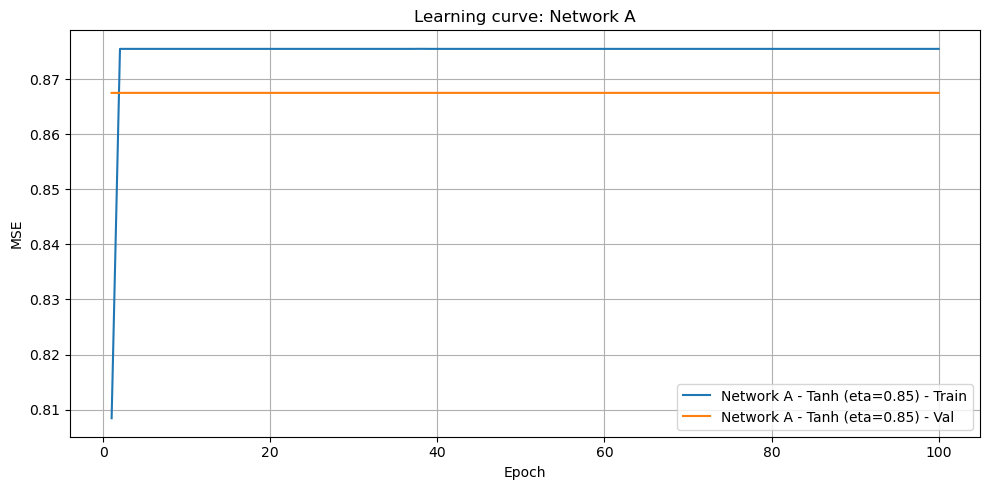

Figure saved to figures/learning_curve_network_a.png
Saved → export/networkA/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA/trained_weights.csv


In [ ]:
epochA.label = "Network A - Tanh (eta=0.85, alpha=0.9, size=8)"

train(epochA, "Learning curve: Network A") #network A

epochA.exportAll("export/networkA/")

### Improvements for Network A

Given that the error does not converge with the default parameters, the following adjustments are applied: the learning rate is reduced from 0.85 to **0.1**, momentum is reduced from 0.9 to **0.5**, and the hidden layer size is increased from 8 to **12**.

These modifications address the core issue of the default configuration: overly large weight updates that prevent convergence to a stable minimum of the loss surface.

Epoch    5  Train: 0.36787  Val: 0.34531  Misc: 8275  Time: 0.486s
Epoch   10  Train: 0.12425  Val: 0.13106  Misc: 2015  Time: 0.578s
Epoch   15  Train: 0.06357  Val: 0.05766  Misc: 974  Time: 0.503s
Epoch   20  Train: 0.04466  Val: 0.03434  Misc: 670  Time: 0.495s
Epoch   25  Train: 0.03435  Val: 0.02670  Misc: 492  Time: 0.489s
Epoch   30  Train: 0.02975  Val: 0.02032  Misc: 448  Time: 0.518s
Epoch   35  Train: 0.02554  Val: 0.02790  Misc: 367  Time: 0.505s
Epoch   40  Train: 0.02205  Val: 0.02006  Misc: 316  Time: 0.504s
Epoch   45  Train: 0.02067  Val: 0.01311  Misc: 290  Time: 0.511s
Epoch   50  Train: 0.01872  Val: 0.02468  Misc: 269  Time: 0.498s
Epoch   55  Train: 0.01759  Val: 0.04607  Misc: 255  Time: 0.508s
Epoch   60  Train: 0.01645  Val: 0.01952  Misc: 230  Time: 0.565s
Epoch   65  Train: 0.01512  Val: 0.01179  Misc: 206  Time: 0.488s
Epoch   70  Train: 0.01459  Val: 0.01947  Misc: 197  Time: 0.569s
Epoch   75  Train: 0.01285  Val: 0.01207  Misc: 180  Time: 0.492s
Epoch   

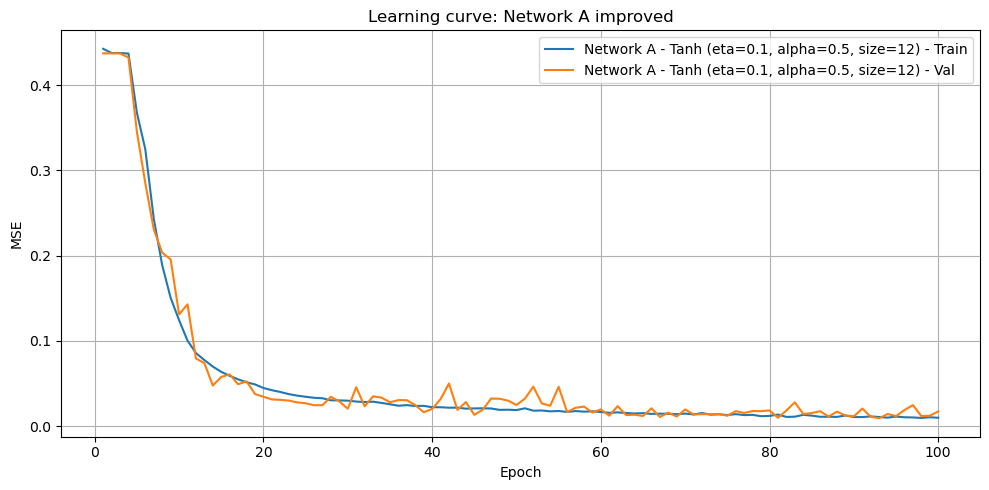

Figure saved to figures/learning_curve_network_a_improved.png
Saved → export/networkA_improv/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv/trained_weights.csv


In [26]:
NetworkA['eta'] = 0.1 #lowering the learning rate
NetworkA['alpha'] = 0.5 #lowering the momentum
NetworkA['size'] = 12 #increasing the number of hidden layers

epochA_improv = Epoch(split, NetworkA)

epochA_improv.label = "Network A - Tanh (eta=0.1, alpha=0.5, size=12)"

train(epochA_improv, "Learning curve: Network A improved")
epochA_improv.exportAll("export/networkA_improv/")

The errors are now converging, although the validation error remains quite erratic relative to the training error. Training time is unchanged even with additional hidden layer nodes, suggesting a hardware or algorithmic bottleneck. Since convergence occurred early, training could reasonably be halted around the **60th epoch**; however, 100 epochs are maintained to target an error below **0.02**.

### Lowering the Learning Rate Further

The next experiment examines whether a further reduction in learning rate improves accuracy or convergence speed.

Epoch    5  Train: 0.43770  Val: 0.43750  Misc: 10790  Time: 0.548s
Epoch   10  Train: 0.34399  Val: 0.34071  Misc: 7523  Time: 0.650s
Epoch   15  Train: 0.17128  Val: 0.15162  Misc: 2827  Time: 0.495s
Epoch   20  Train: 0.08716  Val: 0.08752  Misc: 1297  Time: 0.504s
Epoch   25  Train: 0.05609  Val: 0.04612  Misc: 828  Time: 0.580s
Epoch   30  Train: 0.04358  Val: 0.03606  Misc: 649  Time: 0.564s
Epoch   35  Train: 0.03570  Val: 0.02563  Misc: 513  Time: 0.556s
Epoch   40  Train: 0.02934  Val: 0.02413  Misc: 431  Time: 0.579s
Epoch   45  Train: 0.02643  Val: 0.01893  Misc: 380  Time: 0.573s
Epoch   50  Train: 0.02277  Val: 0.01842  Misc: 312  Time: 0.577s
Epoch   55  Train: 0.02080  Val: 0.02907  Misc: 271  Time: 0.566s
Epoch   60  Train: 0.01945  Val: 0.02796  Misc: 263  Time: 0.551s
Epoch   65  Train: 0.01733  Val: 0.02162  Misc: 227  Time: 0.568s
Epoch   70  Train: 0.01588  Val: 0.02406  Misc: 203  Time: 0.580s
Epoch   75  Train: 0.01481  Val: 0.02154  Misc: 200  Time: 0.568s
Epoch

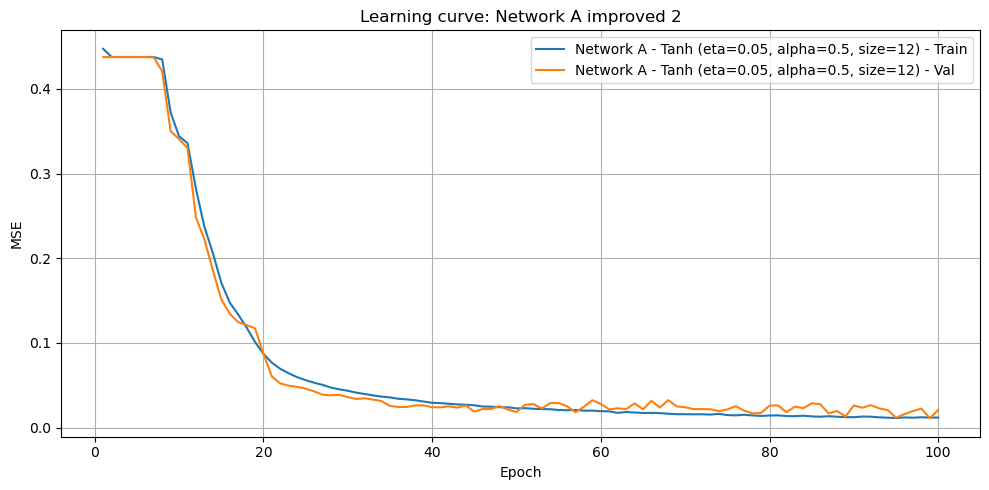

Figure saved to figures/learning_curve_network_a_improved_2.png
Saved → export/networkA_improv2/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2/trained_weights.csv


In [27]:
NetworkA['eta'] = 0.05 #decreasing learning rate to check if performance increases
NetworkA['alpha'] = 0.5 #keeping momentum
NetworkA['size'] = 12 #keeping same number 


epochA_improv2 = Epoch(split, NetworkA)
epochA_improv2.label = "Network A - Tanh (eta=0.05, alpha=0.5, size=12)"

train(epochA_improv2, "Learning curve: Network A improved 2")
epochA_improv2.exportAll("export/networkA_improv2/")

Convergence starts to kick in after 10 epochs.

The final error achieved is roughly equivalent to that of the previous configuration, suggesting the learning rate is near its optimal value for this architecture. However, the full **100 epochs** are required for the training error to fall below 0.02, as expected given that the learning rate was halved. There was a time when both validation error hit an all time low at around **95 epochs**.

The **validation error** exhibits greater instability in this run. Training time is marginally slower at approximately 59 seconds, though the difference remains negligible.

### Increasing Momentum

In the following experiment, momentum is increased. Earlier convergence is anticipated, as higher momentum accelerates weight updates along consistent gradient directions.

Epoch    5  Train: 0.14886  Val: 0.12816  Misc: 2599  Time: 0.606s
Epoch   10  Train: 0.06450  Val: 0.08393  Misc: 970  Time: 0.781s
Epoch   15  Train: 0.04744  Val: 0.03107  Misc: 708  Time: 0.663s
Epoch   20  Train: 0.03612  Val: 0.01776  Misc: 522  Time: 0.676s
Epoch   25  Train: 0.03119  Val: 0.01635  Misc: 449  Time: 0.638s
Epoch   30  Train: 0.02547  Val: 0.02981  Misc: 361  Time: 0.657s
Epoch   35  Train: 0.02610  Val: 0.03074  Misc: 362  Time: 0.780s
Epoch   40  Train: 0.02253  Val: 0.02588  Misc: 310  Time: 0.638s
Epoch   45  Train: 0.02181  Val: 0.01464  Misc: 302  Time: 0.670s
Epoch   50  Train: 0.02009  Val: 0.02538  Misc: 284  Time: 0.702s
Epoch   55  Train: 0.01745  Val: 0.01752  Misc: 239  Time: 0.644s
Epoch   60  Train: 0.01886  Val: 0.01546  Misc: 271  Time: 0.673s
Epoch   65  Train: 0.01578  Val: 0.01571  Misc: 215  Time: 0.782s
Epoch   70  Train: 0.01856  Val: 0.01713  Misc: 265  Time: 0.698s
Epoch   75  Train: 0.01507  Val: 0.01713  Misc: 210  Time: 0.648s
Epoch   8

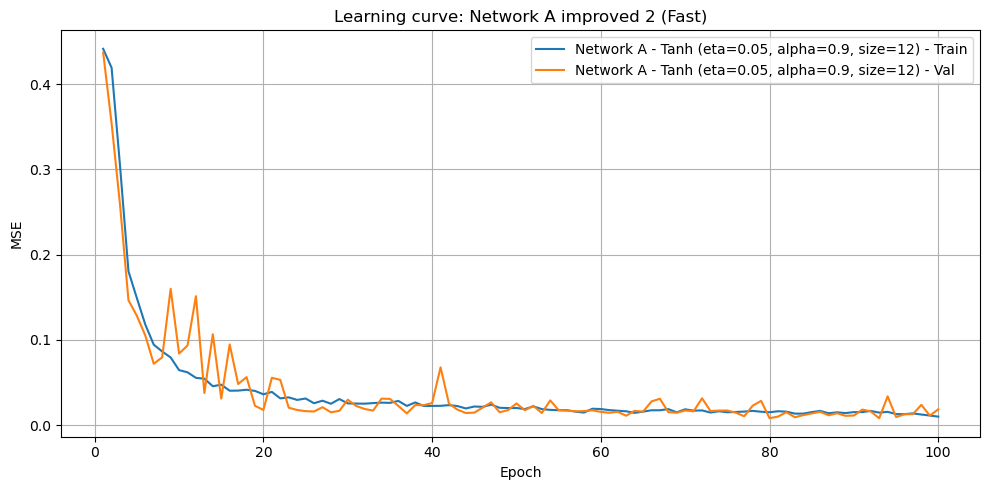

Figure saved to figures/learning_curve_network_a_improved_2_(fast).png
Saved → export/networkA_improv2_fast/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2_fast/trained_weights.csv


In [28]:
NetworkA['eta'] = 0.05 #keep
NetworkA['alpha'] = 0.9 #increasing momentum back
NetworkA['size'] = 12 #keeping size


epochA_improv2_fast = Epoch(split, NetworkA)
epochA_improv2_fast.label = "Network A - Tanh (eta=0.05, alpha=0.9, size=12)"

train(epochA_improv2_fast, "Learning curve: Network A improved 2 (Fast)")
epochA_improv2_fast.exportAll("export/networkA_improv2_fast/")

As anticipated, the higher momentum restores early-epoch convergence, with the training error falling below the target at approximately **epoch 55**. Total training time remains approximately 60 seconds for 100 epochs; however, the ability to halt training at epoch 55 represents a potential reduction in training time of more than half. Values at the end are also very low, achieving equivalent results as the first improvement setup.

### Reducing Hidden Layer Size

The final experiment for Network A examines the effect of reducing the hidden layer size, retaining the current learning rate and momentum settings.

Epoch    5  Train: 0.20755  Val: 0.15188  Misc: 3855  Time: 0.418s
Epoch   10  Train: 0.09306  Val: 0.10377  Misc: 1502  Time: 0.418s
Epoch   15  Train: 0.06177  Val: 0.04028  Misc: 928  Time: 0.418s
Epoch   20  Train: 0.04739  Val: 0.04981  Misc: 732  Time: 0.417s
Epoch   25  Train: 0.03910  Val: 0.02771  Misc: 590  Time: 0.418s
Epoch   30  Train: 0.03581  Val: 0.02288  Misc: 549  Time: 0.418s
Epoch   35  Train: 0.03303  Val: 0.02657  Misc: 493  Time: 0.417s
Epoch   40  Train: 0.02974  Val: 0.03455  Misc: 442  Time: 0.417s
Epoch   45  Train: 0.02647  Val: 0.01435  Misc: 392  Time: 0.417s
Epoch   50  Train: 0.02381  Val: 0.02293  Misc: 365  Time: 0.417s
Epoch   55  Train: 0.02914  Val: 0.01797  Misc: 457  Time: 0.417s
Epoch   60  Train: 0.02189  Val: 0.01959  Misc: 327  Time: 0.417s
Epoch   65  Train: 0.02633  Val: 0.02785  Misc: 382  Time: 0.418s
Epoch   70  Train: 0.02031  Val: 0.02831  Misc: 304  Time: 0.417s
Epoch   75  Train: 0.01958  Val: 0.01637  Misc: 285  Time: 0.422s
Epoch   

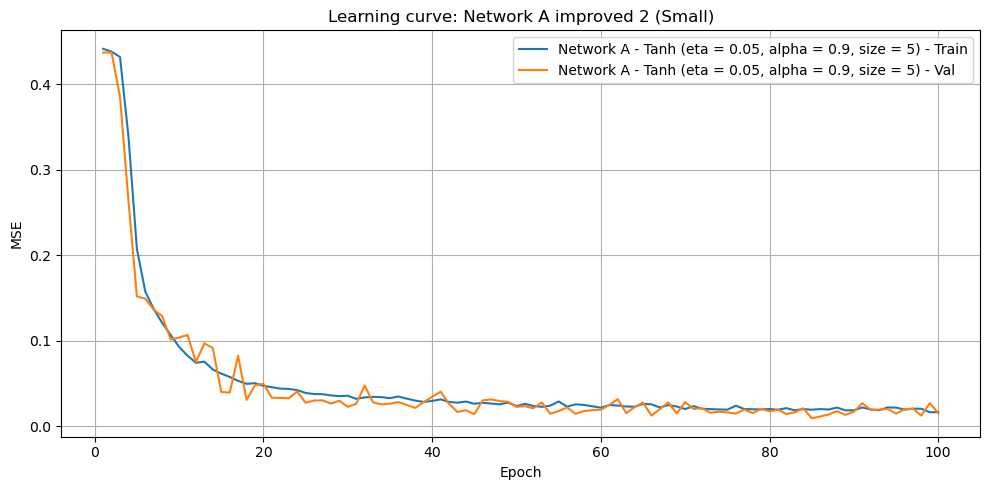

Figure saved to figures/learning_curve_network_a_improved_2_(small).png
Saved → export/networkA_improv2_small/confusion_matrix.csv  shape: 8 classes
Saved → export/networkA_improv2_small/trained_weights.csv


In [ ]:
NetworkA['eta'] = 0.05 #keeping learning rate further
NetworkA['alpha'] = 0.9 #increasing momentum back
NetworkA['size'] = 5 #lowering size 


epochA_improv2_small = Epoch(split, NetworkA)
epochA_improv2_small.label = "Network A - Tanh (eta=0.05, alpha=0.9, size=5)"
train(epochA_improv2_small, "Learning curve: Network A improved 2 (Small)")
epochA_improv2_small.exportAll("export/networkA_improv2_small/")

The network struggles to maintain a training error below 0.02 for both training and validation sets. This behavior is consistent with insufficient representational capacity, suggesting that a larger network or extended training duration is required when the model size is reduced.

However, it was noted that the base speed of training at 100 epochs is considerably faster than changing the hyperparameters or learning rate, while maintaining convergence. Therefore, **lowering the size** can be a good alternative in reducing training time rather than cutting the number of epochs in half.

## Training: Network B

Network B employs the **Leaky ReLU** activation function for both hidden layers and the **Logistic** function for the output layer. Training begins with the default hyperparameters to establish a baseline.

Epoch    5  Train: 0.44919  Val: 0.44675  Misc: 10737  Time: 0.489s
Epoch   10  Train: 0.44919  Val: 0.44675  Misc: 10737  Time: 0.533s
Epoch   15  Train: 0.44919  Val: 0.44675  Misc: 10732  Time: 0.486s
Epoch   20  Train: 0.44918  Val: 0.44674  Misc: 10734  Time: 0.493s
Epoch   25  Train: 0.44917  Val: 0.44671  Misc: 10734  Time: 0.491s
Epoch   30  Train: 0.44890  Val: 0.44567  Misc: 10643  Time: 0.474s


/var/folders/ml/vnv07r1j5lq9xn91hby78kkh0000gt/T/ipykernel_58124/621747645.py:3: RuntimeWarning: overflow encountered in exp
  phi = 1.0 / (1.0 + np.exp(-a * v))


Epoch   35  Train: 0.41277  Val: 0.40637  Misc: 9289  Time: 0.475s
Epoch   40  Train: 0.77951  Val: 0.88875  Misc: 10397  Time: 0.494s
Epoch   45  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.519s
Epoch   50  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.509s
Epoch   55  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.520s
Epoch   60  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.506s
Epoch   65  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.503s
Epoch   70  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.522s
Epoch   75  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.513s
Epoch   80  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.499s
Epoch   85  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.513s
Epoch   90  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.505s
Epoch   95  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.494s
Epoch  100  Train: 0.87410  Val: 0.88875  Misc: 10664  Time: 0.471s
Confusion Matrix (rows=Actual, cols=Predicted):
 

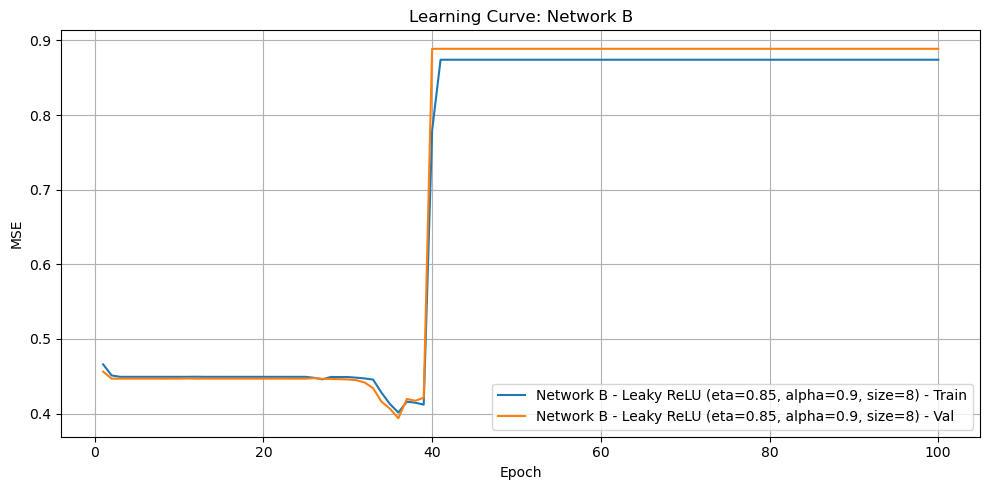

Figure saved to figures/learning_curve_network_b.png
Saved → export/networkB/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB/trained_weights.csv


In [31]:
epochB.label = "Network B - Leaky ReLU (eta=0.85, alpha=0.9, size=8)"

train(epochB, "Learning Curve: Network B") #network B
epochB.exportAll("export/networkB/")

### Improvements: Network B

The default learning rate of 0.85 is again too high; the training error does not decrease across any epoch, consistent with the behavior observed in Network A. The same tuning strategy is applied: `eta=0.1`, `alpha=0.5`, `size=12`.

Epoch    5  Train: 0.43785  Val: 0.43743  Misc: 10820  Time: 0.825s
Epoch   10  Train: 0.31707  Val: 0.28910  Misc: 6702  Time: 0.706s
Epoch   15  Train: 0.11828  Val: 0.15635  Misc: 1903  Time: 0.783s
Epoch   20  Train: 0.07080  Val: 0.06294  Misc: 1070  Time: 0.715s
Epoch   25  Train: 0.04802  Val: 0.03892  Misc: 696  Time: 0.639s
Epoch   30  Train: 0.03728  Val: 0.04034  Misc: 540  Time: 0.681s
Epoch   35  Train: 0.03157  Val: 0.07191  Misc: 432  Time: 0.684s
Epoch   40  Train: 0.02702  Val: 0.02024  Misc: 366  Time: 0.661s
Epoch   45  Train: 0.02405  Val: 0.04539  Misc: 332  Time: 0.689s
Epoch   50  Train: 0.02287  Val: 0.04590  Misc: 327  Time: 0.675s
Epoch   55  Train: 0.02063  Val: 0.07557  Misc: 300  Time: 0.670s
Epoch   60  Train: 0.01906  Val: 0.03347  Misc: 270  Time: 0.829s
Epoch   65  Train: 0.01898  Val: 0.06330  Misc: 272  Time: 0.824s
Epoch   70  Train: 0.01753  Val: 0.02497  Misc: 249  Time: 0.704s
Epoch   75  Train: 0.01748  Val: 0.05560  Misc: 252  Time: 0.822s
Epoch

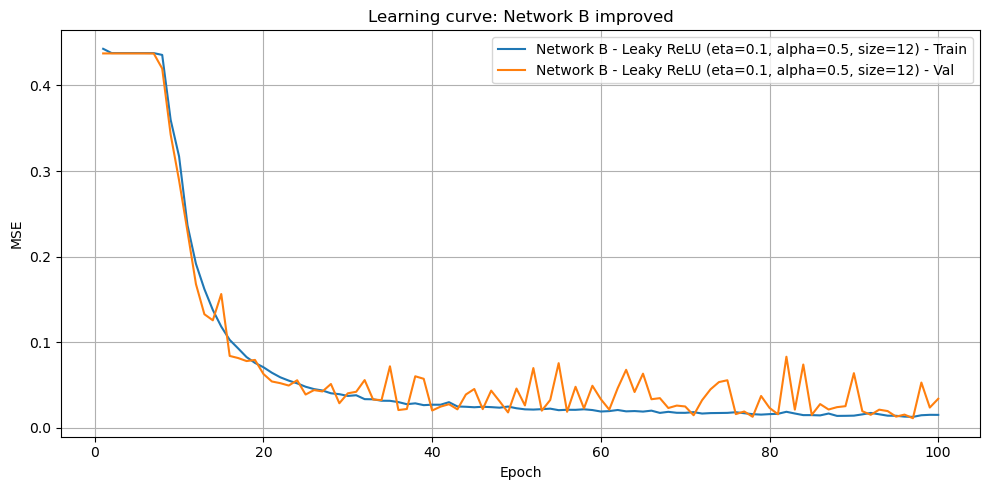

Figure saved to figures/learning_curve_network_b_improved.png
Saved → export/networkB_improv/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv/trained_weights.csv


In [32]:
NetworkB['eta'] = 0.1 #decreasing the learning rate like Network A improv
NetworkB['alpha'] = 0.5 #decreasing the momentum
NetworkB['size'] = 12 #increasing hidden layer nodes

epochB_improv = Epoch(split, NetworkB)
epochB_improv.label = "Network B - Leaky ReLU (eta=0.1, alpha=0.5, size=12)"
train(epochB_improv, "Learning curve: Network B improved")
epochB_improv.exportAll("export/networkB_improv/")

Now the errors converge from around **epoch 10 onwards**. Matthews Correlation Coefficient was noted to be slighly lower at 0.95, which is shown by the spiking nature of the validation error. In fact, errors at earlier epochs, notably at around **epochs 85 and 95** have very low errors. Due to this, a stopping criteria may be necessary to fully take advantage of the nature of the ReLU.

Alternatively, a more aggressive clipping method may need to be introduced, though this is outside the scope of the study.

### Lowering the Learning Rate Further



Epoch    5  Train: 0.43770  Val: 0.43753  Misc: 10801  Time: 0.978s
Epoch   10  Train: 0.43770  Val: 0.43752  Misc: 10799  Time: 0.979s
Epoch   15  Train: 0.43704  Val: 0.43566  Misc: 10336  Time: 0.974s
Epoch   20  Train: 0.26980  Val: 0.24305  Misc: 5016  Time: 1.107s
Epoch   25  Train: 0.14148  Val: 0.14892  Misc: 2173  Time: 0.734s
Epoch   30  Train: 0.07191  Val: 0.06674  Misc: 1032  Time: 0.908s
Epoch   35  Train: 0.05087  Val: 0.03909  Misc: 701  Time: 0.916s
Epoch   40  Train: 0.03835  Val: 0.03472  Misc: 524  Time: 0.959s
Epoch   45  Train: 0.03240  Val: 0.02770  Misc: 447  Time: 1.082s
Epoch   50  Train: 0.02821  Val: 0.02612  Misc: 391  Time: 1.077s
Epoch   55  Train: 0.02608  Val: 0.03598  Misc: 350  Time: 0.948s
Epoch   60  Train: 0.02306  Val: 0.02181  Misc: 333  Time: 0.890s
Epoch   65  Train: 0.01989  Val: 0.03135  Misc: 266  Time: 0.915s
Epoch   70  Train: 0.01955  Val: 0.05587  Misc: 275  Time: 1.098s
Epoch   75  Train: 0.01846  Val: 0.02402  Misc: 257  Time: 0.922s
E

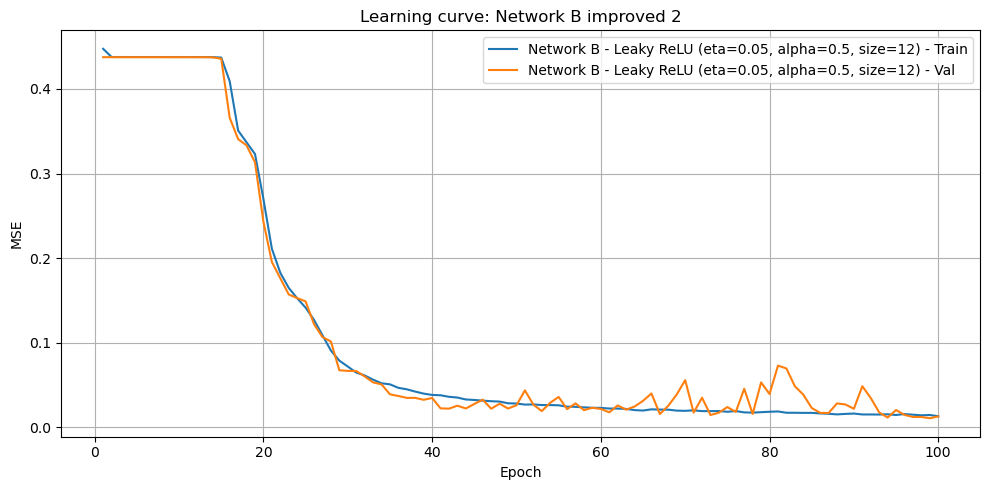

Figure saved to figures/learning_curve_network_b_improved_2.png
Saved → export/networkB_improv2/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2/trained_weights.csv


In [34]:
NetworkB['eta'] = 0.05 #decreasing the learning rate like Network A improv2
NetworkB['alpha'] = 0.5 #keaping the momentum
NetworkB['size'] = 12 #increasing hidden layer nodes

epochB_improv2 = Epoch(split, NetworkB)
epochB_improv2.label = "Network B - Leaky ReLU (eta=0.05, alpha=0.5, size=12)"

train(epochB_improv2, "Learning curve: Network B improved 2")
epochB_improv2.exportAll("export/networkB_improv2/")

Reducing the learning rate further improves the macro F1 score and stabilizes the validation error by the end of the 100-epoch run. However, the network still struggles to maintain a low error in intermediate epochs, with Classes 6 and 8 contributing the most to classification errors. Weight improvement is first observed around epoch 15, which is consistent with the slower learning dynamics introduced by the reduced learning rate.

Training time was really high at 96 seconds, much higher than previous Tanh-Tanh configurations.

Examination of the SMOTE-balanced distribution does not reveal evidence of residual class imbalance as the cause of Class 6 misclassifications, as that class was well-represented in the original dataset and received proportional synthetic augmentation.

### Increasing Momentum

Momentum is increased to determine if tuning the training this way would improve the speed of training, while retaining the performance of lowering the learning rate.

Epoch    5  Train: 0.28664  Val: 0.20855  Misc: 5931  Time: 0.878s
Epoch   10  Train: 0.09202  Val: 0.06535  Misc: 1437  Time: 0.882s
Epoch   15  Train: 0.05942  Val: 0.08635  Misc: 926  Time: 0.858s
Epoch   20  Train: 0.04495  Val: 0.05085  Misc: 691  Time: 0.879s
Epoch   25  Train: 0.03571  Val: 0.04141  Misc: 503  Time: 0.886s
Epoch   30  Train: 0.03153  Val: 0.03398  Misc: 471  Time: 0.874s
Epoch   35  Train: 0.02966  Val: 0.02308  Misc: 427  Time: 0.880s
Epoch   40  Train: 0.02270  Val: 0.02123  Misc: 343  Time: 0.881s
Epoch   45  Train: 0.02485  Val: 0.02602  Misc: 367  Time: 0.869s
Epoch   50  Train: 0.02733  Val: 0.02830  Misc: 388  Time: 0.876s
Epoch   55  Train: 0.02078  Val: 0.01162  Misc: 324  Time: 0.879s
Epoch   60  Train: 0.02550  Val: 0.02511  Misc: 376  Time: 0.865s
Epoch   65  Train: 0.01946  Val: 0.01231  Misc: 291  Time: 0.871s
Epoch   70  Train: 0.01733  Val: 0.01467  Misc: 257  Time: 0.880s
Epoch   75  Train: 0.01849  Val: 0.02470  Misc: 262  Time: 0.862s
Epoch   

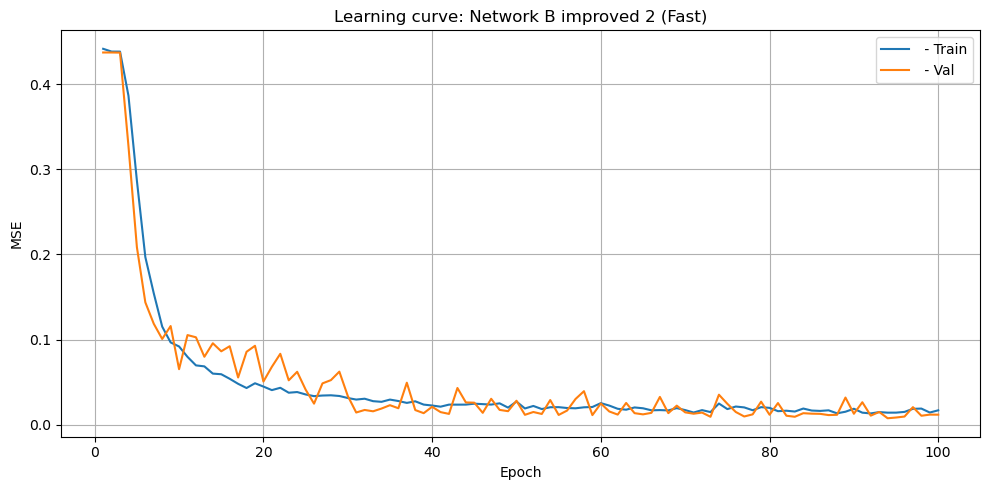

Figure saved to figures/learning_curve_network_b_improved_2_(fast).png
Saved → export/networkB_improv2_fast/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2_fast/trained_weights.csv


In [35]:
NetworkB['eta'] = 0.05 #decreasing the learning rate like Network A improv2
NetworkB['alpha'] = 0.9 #keaping the momentum
NetworkB['size'] = 12 #increasing hidden layer nodes

epochB_improv2_fast = Epoch(split, NetworkB)
epochB_improv2.label = "Network B - Leaky ReLU (eta=0.05, alpha=0.9, size=12)"

train(epochB_improv2_fast, "Learning curve: Network B improved 2 (Fast)")
epochB_improv2_fast.exportAll("export/networkB_improv2_fast/")

This configuration yields a notable improvement. The training error converges erratically with an elevated floor; however, the error approaches this threshold at approximately **epoch 65**. The validation error is slightly less stable than the training error, suggesting reasonable generalization. Changing the momentum seems to "accelerate" training by improving the learning rate characteristics. Total training time seems to be lower as well, though still longer than Tanh counterparts.

### Reducing Hidden Layer Size

The following experiment investigates whether the classification improvements are retained when the hidden layer size is reduced.

Epoch    5  Train: 0.43822  Val: 0.43713  Misc: 10771  Time: 0.446s
Epoch   10  Train: 0.22311  Val: 0.21153  Misc: 4000  Time: 0.456s
Epoch   15  Train: 0.19999  Val: 0.18563  Misc: 3451  Time: 0.442s
Epoch   20  Train: 0.19300  Val: 0.21830  Misc: 3270  Time: 0.446s
Epoch   25  Train: 0.28999  Val: 0.44901  Misc: 5382  Time: 0.443s
Epoch   30  Train: 0.33203  Val: 0.33035  Misc: 6837  Time: 0.514s
Epoch   35  Train: 0.29024  Val: 0.30474  Misc: 5825  Time: 0.499s
Epoch   40  Train: 0.20893  Val: 0.23632  Misc: 4036  Time: 0.440s
Epoch   45  Train: 0.19197  Val: 0.21935  Misc: 3752  Time: 0.440s
Epoch   50  Train: 0.19373  Val: 0.23045  Misc: 3734  Time: 0.440s
Epoch   55  Train: 0.18932  Val: 0.22330  Misc: 3612  Time: 0.440s
Epoch   60  Train: 0.50009  Val: 0.50003  Misc: 10607  Time: 0.484s
Epoch   65  Train: 0.49998  Val: 0.49989  Misc: 10681  Time: 0.490s
Epoch   70  Train: 0.23335  Val: 0.31381  Misc: 4839  Time: 0.439s
Epoch   75  Train: 0.24158  Val: 0.24607  Misc: 4929  Time:

/var/folders/ml/vnv07r1j5lq9xn91hby78kkh0000gt/T/ipykernel_58124/621747645.py:3: RuntimeWarning: overflow encountered in exp
  phi = 1.0 / (1.0 + np.exp(-a * v))


Epoch   90  Train: 0.50000  Val: 0.50000  Misc: 10670  Time: 0.488s
Epoch   95  Train: 0.50000  Val: 0.50000  Misc: 10670  Time: 0.441s
Epoch  100  Train: 0.37523  Val: 0.23908  Misc: 7703  Time: 0.440s
Confusion Matrix (rows=Actual, cols=Predicted):
      P 1  P 2  P 3  P 4  P 5  P 6  P 7  P 8
A 1 |    0     4     0     0     0    84     1     0
A 2 |    0    77     0     3     0     2     0     0
A 3 |    0     0     0     0     0   106     0     0
A 4 |    0     0     0   117     0     0     0     2
A 5 |    0     0     0     0    93     0     0     1
A 6 |    0     6     0     8     0    82     1     9
A 7 |    0     0     0     0     3    12    87     0
A 8 |    0    11     0    17     1    35     4    34

Per-Class Metrics:
  Class        TP     TN     FP     FN  Precision     Recall   F1 Score
  -------- ------ ------ ------ ------ ---------- ---------- ----------
  Class 1       0    711      0     89    0.00000    0.00000    0.00000
  Class 2      77    697     21      5    0.

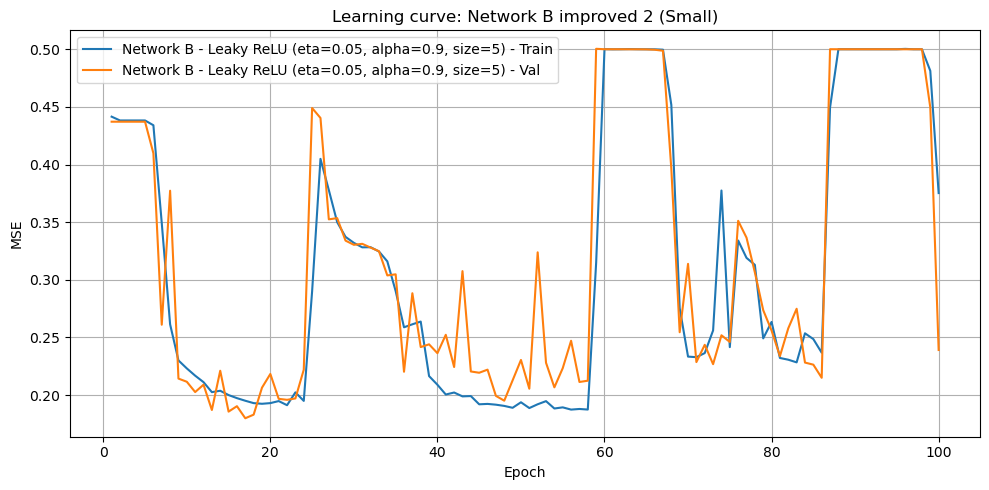

Figure saved to figures/learning_curve_network_b_improved_2_(small).png
Saved → export/networkB_improv2_small/confusion_matrix.csv  shape: 8 classes
Saved → export/networkB_improv2_small/trained_weights.csv


In [36]:
NetworkB['eta'] = 0.05 #keeping the learning rate like Network A improv2 fast
NetworkB['alpha'] = 0.9 #keeping the high momentum
NetworkB['size'] = 5 #decreasing hidden nodes

epochB_improv2_small = Epoch(split, NetworkB)
epochB_improv2_small.label = "Network B - Leaky ReLU (eta=0.05, alpha=0.9, size=5)"

train(epochB_improv2_small, "Learning curve: Network B improved 2 (Small)")
epochB_improv2_small.exportAll("export/networkB_improv2_small/")

Reducing the hidden layer size to 5 nodes improved compute significantly by reducing training time to around 40 seconds. However, the training unfortunately failed to finish in the first 100 epochs. A higher size is needed for Leaky ReLU to be used, compared to Tanh activation method.

# Training Results

After training all network configurations, the results are compiled and ranked by F1 score and approximate epoch of convergence. Time was recorded when convergence was met.

In [53]:
!python checkscores.py

Loaded 1 rows from networkB
Loaded 1 rows from networkA_improv2_small
Loaded 1 rows from networkA_improv2_fast
Loaded 1 rows from networkB_improv2_small
Loaded 1 rows from networkB_improv
Loaded 1 rows from networkA
Loaded 1 rows from networkB_improv2
Loaded 1 rows from networkA_improv2
Loaded 1 rows from networkB_improv2_fast
Loaded 1 rows from networkA_improv

Combined 10 total rows written to combined_scores.csv
Full scores written to final/full_scores.csv
Best score written to final/scores.csv (Network: networkB_improv2, F1: 0.988610)
Results markdown written to final/results.md


In [50]:
epochA.label = "Network A - TanH (eta=0.85, alpha=0.9, size=8)"
epochA_improv.label = "Network A - TanH (eta=0.1, alpha=0.5, size=12)"
epochA_improv2.label = "Network A - TanH (eta=0.05, alpha=0,9, size=12)"
epochA_improv2_fast.label = "Network A - TanH (eta=0.05, alpha=0.9, size=12)"
epochA_improv2_small.label = "Network A - TanH (eta=0.05, alpha=0.9, size=5)"
allepochA = [epochA, epochA_improv, epochA_improv2, epochA_improv2_fast, epochA_improv2_small]


epochB.label = "Network B - ReLU (eta=0.85, alpha=0.9, size=8)"
epochB_improv.label = "Network B - ReLU (eta=0.1, alpha=0.5, size=12)"
epochB_improv2.label = "Network B - ReLU (eta=0.05, alpha=0,9, size=12)"
epochB_improv2_fast.label = "Network B - ReLU (eta=0.05, alpha=0.9, size=12)"
epochB_improv2_small.label = "Network B - ReLU (eta=0.05, alpha=0.9, size=5)"
allepochB = [epochB, epochB_improv, epochB_improv2, epochB_improv2_fast, epochB_improv2_small]

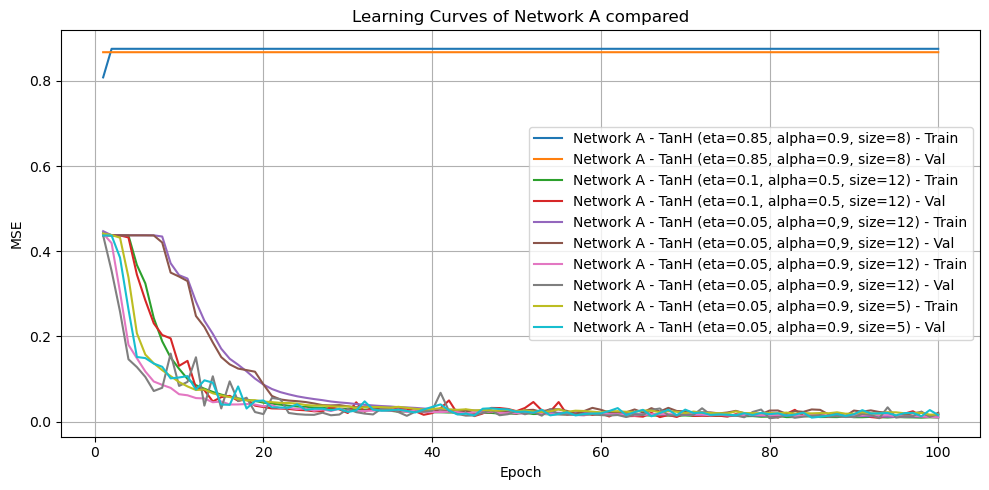

Figure saved to figures/learning_curves_of_network_a_compared.png


In [51]:
learningcurve(allepochA, "Learning Curves of Network A compared")

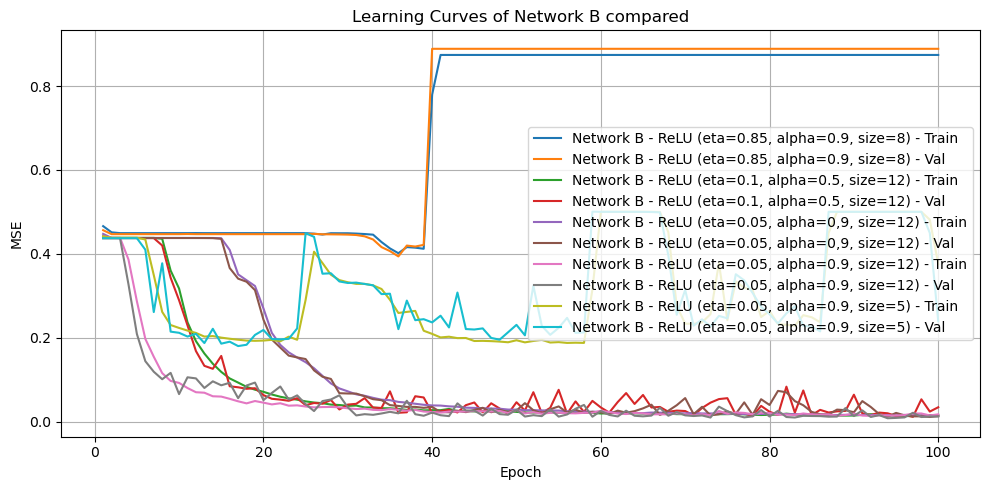

Figure saved to figures/learning_curves_of_network_b_compared.png


In [52]:
learningcurve(allepochB, "Learning Curves of Network B compared")

## Training Observations

After experimentation, the following were observed:

**Activation Function** — The choice of activation function affects both convergence behavior and computational cost. Leaky ReLU exhibited notably erratic validation performance compared to other functions tested.

**Learning Rate** — Controls the speed of learning without significantly impacting per-epoch compute time. A rate that is too high prevents convergence entirely, while a well-chosen rate reduces the number of epochs needed to reach an MSE target.

**Momentum Constant** — Acts as an epoch-skipping effect, stretching the loss curve and accelerating convergence as it increases. It is best tuned after the learning rate is set, serving as a secondary control to balance speed and stability.

**Hidden Layer Size** — Directly affects the MSE floor; smaller layers raise the minimum achievable error, while larger layers improve model capacity at the cost of compute time. This is the primary parameter to adjust when training under hardware constraints.

---

### Recommended Training Strategy

1. Set a **learning rate** $\eta$ high enough for fast convergence, but not so high that it diverges.
2. Slightly lower $\eta$, then raise the **momentum constant** $\alpha$ to recover speed while maintaining stability.
3. Adjust **hidden layer size** based on hardware: reduce it to ease compute load, or increase it to improve accuracy on capable systems.

> **Note:** In Network B, reducing the hidden layer size caused complete failure to converge. Network A still converged under the same condition, but we can observe that in both networks, training time improved significantly.

## Results

### **Ranked by F1 Macro**

| Rank | Network | Epoch (train & val errors < 0.02) | f1\_macro | Notes |
| --- | --- | --- | --- | --- |
| **1** | **networkB_improv2** | 73 | **0.9886104267** | Best model all-around |
| **2** | **networkB_improv2_fast** | 51 | **0.9852983084** | Fast to converge, good balance |
| **3** | **networkA_improv2_fast** | 44 | **0.9835187069** | Fastest, still good balance |
| **4** | **networkA_improv2_small** | 74 | **0.9810832261** | Lower performance, half training time |
| **5** | **networkA_improv** | 56 | **0.9800595241** | Good learning rate, could be improved |
| **6** | **networkA_improv2** | 74 | **0.9760872926** | Lowered learning rate, slower and less accurate |
| **7** | **networkB_improv** | 71 | **0.9612885197** | Good start, needs more tuning|
| **8** | **networkB_improv2_small** | DNF | **0.5564479093** | Did not converge, size too small |
| **9** | **networkA** | DNF | **0.0292494481** | Completely wrong parameters |
| **10** | **networkB** | DNF | **0.0250281215** | Completely wrong parameters |


### Full Scores Results

| Rank | Network | Epoch (MSE<0.02) | F1 Score | MCC | Accuracy | Precision | Recall |
| --- | --- | --- | --- | --- | --- | --- | --- |
| **1** | **networkB_improv2** | 73 | **0.9886104266802997** | 0.9871434813936002 | 0.98875 | 0.9880438764134416 | 0.9893306379155435 |
| **2** | **networkB_improv2_fast** | 51 | **0.985298308383793** | 0.9828614495415673 | 0.985 | 0.9856464558169103 | 0.9851633996825357 |
| **3** | **networkA_improv2_fast** | 44 | **0.9835187068670926** | 0.9801059555388116 | 0.9825 | 0.9839927637721755 | 0.983825881940443 |
| **4** | **networkA_improv2_small** | 74 | **0.9810832261192908** | 0.9786034851115598 | 0.98125 | 0.9812392134852626 | 0.9814406841812409 |
| **5** | **networkA_improv** | 56 | **0.9800595240561725** | 0.9772495150791172 | 0.98 | 0.9804202582393017 | 0.9806557825589426 |
| **6** | **networkA_improv2** | 74 | **0.9760872925642827** | 0.9730911194363044 | 0.97625 | 0.9773195018363925 | 0.9768042419426961 |
| **7** | **networkB_improv** | 71 | **0.9612885197229641** | 0.9548088483566725 | 0.96 | 0.9646664883688096 | 0.9614403902328368 |
| **8** | **networkB_improv2_small** | DNF | **0.5564479093333913** | 0.593441665499621 | 0.6125 | 0.5601799678977939 | 0.6089298481433483 |
| **9** | **networkA** | DNF | **0.02924944812362031** | 0.0 | 0.1325 | 0.0165625 | 0.125 |
| **10** | **networkB** | DNF | **0.025028121484814397** | 0.0 | 0.11125 | 0.01390625 | 0.125 |


### Training Time Results

Adding in a value so that we can compare normalized training time to get an equivalent 0.02 MSE:

$$ \text{Time-Adjusted} = \text{Time} × (\text{Epoch}_{\text{converged}} / 100) $$

Special rules:

* If **Epoch\_converged > 100**, multiplier = **1.00**
* If **DNF**, then Time-Adjusted = **N/A**

| Rank | Network | Epoch | Time (s) | Time-Adjusted | Your Notes |
| --- | --- | --- | --- | --- | --- |
| **1** | **networkB_improv2** | 73 | 96.92362 | **70.75424** | |
| **2** | **networkB_improv2_fast** | 51 | 87.41550 | **44.58191** | |
| **3** | **networkA_improv2_fast** | 44 | 67.50442 | **29.70195** | |
| **4** | **networkA_improv2_small** | 74 | 42.35613 | **31.34354** | |
| **5** | **networkA_improv** | 56 | 52.24818 | **29.25898** | |
| **6** | **networkA_improv2** | 74 | 59.33289 | **43.90634** | |
| **7** | **networkB_improv** | 71 | 74.36175 | **52.79684** | |
| **8** | **networkB_improv2_small** | DNF | 45.96956 | **N/A** | |
| **9** | **networkA** | DNF | 44.12977 | **N/A** | |
| **10** | **networkB** | DNF | 50.06487 | **N/A** | |

A tradeoff exists between peak F1 performance and time-adjusted training cost. Configurations that fail to converge are disqualified regardless of raw metric values. Among converging configurations, **networkA\_improv2\_fast** offers the most favorable balance of F1 score and adjusted training time.

### Best Network A

**Network A (improved2, Fast)** with Tanh achieves the best overall result for Network A, recording a macro-averaged **F1 score of 0.98351** and meeting the below 0.02 MSE target at epoch 44. With early stopping applied, the adjusted training time is approximately **29.7 seconds**. Its trained weights are exported to `modelA/trained_weights.csv` as the main model for the unseen test set. A close second, **Network A (improved2, Small)**, achieves a marginally lower **F1 score of 0.98108** but has higher errors on average and converges around the same time at **31.3 seconds** as the stopping point at epoch 74. It could have been potentially "faster" but the tradeoff of speed is not rationalized since changing the momentum alone proved to be still faster.

### Best Network B

**Network B (improved2, Fast)** with Leaky ReLU is the best configuration for Network B, recording a **macro-averaged F1 score of 0.98861**. Target errors happen at approximately epoch 73, yielding an adjusted training time of approximately **70.8 seconds**. Its weights are exported to `modelB/trained_weights.csv` as the primary ReLU model.

### About the default configuration

The two default-parameter configurations failed to converge entirely, yielding F1 scores of 0.2 each with MCC values of 0, confirming that no meaningful learning occurred.

## Chosen Models

Therefore, the best model for each Network is as follows:

| Model | Network |
| --- | --- |
|  Network A (Tanh)   |   - **networkA_improv2_fast** with the higher momentum constant   |
|   Network B (Leaky ReLU)  |    - **networkB_improv2** lower momentum constant, but highest F1 score  |

### Loading the Models

Trained weights are loaded from CSV files using the `loadWeights` function. The function reads the weight matrix, parses the layer dimensions, and returns properly shaped arrays ready for reconstruction.

In [55]:
epochA_improv2_fast.exportWeights("modelA/")
epochB_improv2.exportWeights("modelB/")

Saved → modelA/trained_weights.csv
Saved → modelB/trained_weights.csv


In [58]:
def loadWeights(path):
    blocks = {'Wi': [], 'Wj': [], 'Wk': []}
    current = None
    with open(path, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row or row[0].strip() == '':
                continue
            tag = row[0].strip()
            if tag in blocks:
                current = tag
                continue
            if current is not None:
                blocks[current].append([float(v) for v in row])
    return (np.array(blocks['Wi']),
            np.array(blocks['Wj']),
            np.array(blocks['Wk']))

## Running and Exporting the Predictions

The `runPredictions` function takes the loaded weights and test set, reconstructs the network layers, and performs a forward pass for each test sample. Predictions are determined by taking the `argmax` of the output layer activations.

The best two models are used:
- **Network B improved** (Leaky ReLU) → `predictions/networkB_improv_predictions.csv`
- **Network A improved fast** (Tanh) → `predictions/networkA_improv_fast_predictions.csv`

In [59]:
def runPredictions(model, testset, cfg):
    if isinstance(model, tuple):
        Wi, Wj, Wk = model
        layerI = HiddenLayer(cfg['methods'][0], Wi, cfg, size=Wi.shape[0])
        layerJ = HiddenLayer(cfg['methods'][1], Wj, cfg, size=Wj.shape[0])
        layerK = OutputLayer(cfg['methods'][2], Wk, cfg)
    else:
        layerI = model.hiddenlayer_i
        layerJ = model.hiddenlayer_j
        layerK = model.outputlayer_k

    predictions = []
    for x in testset:
        xb   = np.concatenate(([1.0], np.asarray(x, dtype=float)))
        phiI = layerI.forward(xb)
        phiJ = layerJ.forward(phiI)
        layerK.forward(phiJ)
        label = int(np.argmax(layerK.o)) + 1
        predictions.append(label)
    return predictions

def exportPredictions(predictions, filename="predictions_for_test_networkA.csv"):
    outputdir = "predictions"
    os.makedirs(outputdir, exist_ok=True)
    filepath = os.path.join(outputdir, filename)
    with open(filepath, 'w', newline='') as f:
        writer = csv.writer(f)
        for p in predictions:
            writer.writerow([p])
    print(f"Saved {len(predictions)} predictions → {filepath}")

In [60]:
#for sanity's sake, this is the parsed  TESTSET from test_set.csv
print(TESTSET)
print(f"TESTSET : {TESTSET.shape}")

[[2.2071e-02 1.5208e-02 0.0000e+00 ... 4.9787e-03 9.8536e-01 6.6436e-02]
 [2.7050e-02 1.4022e-02 8.7247e-04 ... 2.5246e-02 9.0283e-01 2.7611e-01]
 [4.0489e-02 2.9229e-02 1.7990e-03 ... 1.0859e-02 9.2096e-01 2.6831e-01]
 ...
 [1.6607e-02 2.0379e-02 5.2598e-04 ... 4.4773e-03 9.8416e-01 8.9833e-02]
 [5.6162e-03 5.2749e-03 0.0000e+00 ... 7.8382e-03 9.7868e-01 1.4204e-01]
 [1.1618e-02 1.1367e-02 1.9311e-04 ... 9.4570e-03 8.8809e-01 2.1509e-01]]
TESTSET : (701, 354)


In [61]:
WEIGHTSA = os.path.join("modelA", "trained_weights.csv") #tanh
WEIGHTSB = os.path.join("modelB", "trained_weights.csv") #leakyrelu

MODELA = loadWeights(WEIGHTSA)
MODELB = loadWeights(WEIGHTSB)

predictions_tanh = runPredictions(MODELA, TESTSET, NetworkA)
predictions_relu = runPredictions(MODELB, TESTSET, NetworkB)

#exporting predictions
exportPredictions(predictions_tanh, filename="predictions_for_test_tanh.csv")
exportPredictions(predictions_relu, filename="predictions_for_test_leakyrelu.csv")


Saved 701 predictions → predictions/predictions_for_test_tanh.csv
Saved 701 predictions → predictions/predictions_for_test_leakyrelu.csv


# Conclusion and Recommendations

This study evaluated ten Multilayer Perceptron configurations across two activation-function families, Tanh and Leaky ReLU, by varying the learning rate ($\eta$), momentum constant ($\alpha$), and hidden-layer size. The conclusions below follow the ranked results and selected models reported in the **Training Results** section.

## Conclusions

1. **The default configuration was not usable.** The baseline `networkA` and `networkB` runs both failed to converge and ranked last, with macro F1 scores of **0.02925** and **0.02503** respectively. This confirms that the original $\eta = 0.85$ and $\alpha = 0.9$ setting was too aggressive for this task.

2. **Lowering the learning rate was the main factor that enabled successful training.** Once $\eta$ was reduced to **0.1** or **0.05**, both network families produced strong models. The top overall result came from **`networkB_improv2`**, which achieved a macro F1 score of **0.98861** and reached the target error threshold at **epoch 73**.

3. **Higher momentum improved speed after the learning rate had been stabilized.** This is most visible in **`networkA_improv2_fast`**, which reached the error target by **epoch 44** with a macro F1 score of **0.98352** and the best time-adjusted training cost among converging models. For Network B, **`networkB_improv2_fast`** also reduced convergence time to **epoch 51** while maintaining a strong macro F1 score of **0.98530**.

4. **A hidden-layer size of 12 was more reliable than 5.** Reducing the hidden size to 5 remained acceptable for Tanh (`networkA_improv2_small`, macro F1 **0.98108**), but it clearly weakened Leaky ReLU (`networkB_improv2_small`), which did not finish successfully and dropped to a macro F1 score of **0.55645**.

5. **Leaky ReLU delivered the highest peak accuracy, while Tanh offered the best efficiency-accuracy balance.** The two highest-ranked models overall were the Leaky ReLU variants `networkB_improv2` and `networkB_improv2_fast`, but the Training Results section also shows that **`networkA_improv2_fast`** is the strongest time-efficient choice among the converging models.

## Recommendations

- **For the highest predictive performance**, use **`networkB_improv2`** as the primary model because it achieved the best overall macro F1 score (**0.98861**).

- **For the strongest speed-performance tradeoff**, use **`networkA_improv2_fast`**. It converged by **epoch 44**, achieved a macro F1 score of **0.98352**, and had the lowest time-adjusted training cost among the successful runs.

- **For model selection in this notebook**, retain the chosen pair already identified in the Training Results section: **`networkA_improv2_fast`** for Tanh and **`networkB_improv2`** for Leaky ReLU.

- **For future work**, implement formal early stopping based on validation error and apply SMOTE only after the train-validation split so the validation set remains fully independent.